# Proyecto: Análisis exploratorio de datos para decisiones comerciales
---
## Tabla de Contenidos
- [Introducción y Documentación](./README.md)
- [Desarrollo](#development)
  - [1. Análisis Exploratorio de Datos](#lesson1)
  - [2. Conceptos Básicos de Estadística Descriptiva](#lesson2)
  - [3. Correlación](#lesson3)
  - [4. Regresiones Lineales](#lesson4)
  - [5. Análisis Visual de Datos](#lesson5)
  - [6. Librería Matplotlib](#lesson6)
- [Reporte Técnico](./technical_report.md)
---

## [Introducción y Documentación](./README.md)
## Desarrollo <a id="development"></a>

### 1. Análisis Exploratorio de Datos <a id="lesson1"></a>

El Análisis Exploratorio de Datos (EDA) es el proceso de examinar un dataset antes de aplicar modelos formales.
El objetivo es entender su estructura, detectar anomalías y formular hipótesis iniciales.
A diferencia del análisis confirmatorio, el EDA no parte de supuestos previos: deja que los datos "hablen".

#### 1.1 Generación del dataset

In [ ]:
import numpy as np
import pandas as pd
import os

# Asegurar existencia de directorios
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Semilla para reproducibilidad
rng = np.random.default_rng(seed=42)

# Tamaño del dataset
N = 200

# Variables categóricas
categories = ["Norte", "Sur", "Centro", "Oriente"]
segments = ["Premium", "Estándar", "Básico"]

region = rng.choice(categories, size=N, p=[0.25, 0.20, 0.35, 0.20])
segment = rng.choice(segments, size=N, p=[0.20, 0.50, 0.30])

# Variables numéricas
age = rng.integers(18, 70, size=N)
visits = rng.integers(1, 30, size=N)
purchase_amount = (
    visits * rng.uniform(8, 25, size=N) + rng.normal(0, 30, size=N)
).round(2)

# Tasa de devoluciones: correlacionada negativamente con purchase_amount
return_rate = np.clip(
    (100 - purchase_amount * 0.15 + rng.normal(0, 10, size=N)) / 100, 0, 1
).round(3)

# Puntuación de reseña (1-5), correlacionada positivamente con purchase_amount
review_score = np.clip(purchase_amount / 100 + rng.normal(3, 0.8, size=N), 1, 5).round(
    1
)

# Introducir valores faltantes de forma aleatoria (~5%)
missing_idx_age = rng.choice(N, size=8, replace=False)
missing_idx_review = rng.choice(N, size=10, replace=False)
age = age.astype(float)
age[missing_idx_age] = np.nan
review_score[missing_idx_review] = np.nan

df = pd.DataFrame(
    {
        "client_id": range(1, N + 1),
        "region": region,
        "segment": segment,
        "age": age,
        "visits": visits,
        "purchase_amount": purchase_amount,
        "return_rate": return_rate,
        "review_score": review_score,
    }
)

# Guardar dataset para referencia futura
df.to_csv("data/data_comercioya.csv", index=False)

print(f"Dataset generado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Archivo exportado: data/data_comercioya.csv")

Dataset generado: 200 filas × 8 columnas
Archivo exportado: data/data_comercioya.csv


In [ ]:
df.head(10)

,client_id,region,segment,age,visits,purchase_amount,return_rate,review_score
0,1,Centro,Básico,18.0,24,438.69,0.314,5.0
1,2,Sur,Básico,33.0,22,501.55,0.237,5.0
2,3,Oriente,Estándar,44.0,17,404.72,0.415,5.0
3,4,Centro,Premium,65.0,26,567.07,0.211,5.0
4,5,Norte,Premium,56.0,4,97.86,0.753,3.9
5,6,Oriente,Estándar,58.0,27,581.02,0.024,5.0
6,7,Centro,Premium,46.0,25,535.59,0.307,5.0
7,8,Centro,Estándar,23.0,15,161.01,0.717,4.7
8,9,Norte,Premium,38.0,22,451.73,0.181,5.0
9,10,Centro,Estándar,69.0,16,208.62,0.731,5.0


#### 1.2 Distinción de variables: cuantitativas y categóricas

In [ ]:
# Clasificamos las columnas según su tipo semántico
categorical_cols = ["region", "segment"]
numeric_cols = ["age", "visits", "purchase_amount", "return_rate", "review_score"]

print("Variables categóricas:", categorical_cols)
print("Variables numéricas  :", numeric_cols)
print()
print(df.dtypes)

Variables categóricas: ['region', 'segment']
Variables numéricas  : ['age', 'visits', 'purchase_amount', 'return_rate', 'review_score']

client_id            int64
region                 str
segment                str
age                float64
visits               int64
purchase_amount    float64
return_rate        float64
review_score       float64
dtype: object


In [ ]:
# Distribución de frecuencias para variables categóricas
print("=== Distribución por región ===")
print(df["region"].value_counts())
print()
print("=== Distribución por segmento ===")
print(df["segment"].value_counts())

=== Distribución por región ===
region
Centro     74
Norte      50
Sur        41
Oriente    35
Name: count, dtype: int64

=== Distribución por segmento ===
segment
Estándar    96
Básico      59
Premium     45
Name: count, dtype: int64


#### 1.3 Detección de valores faltantes e inconsistencias (IDA)

In [ ]:
# Análisis Inicial de Datos (IDA): revisión de nulos y tipos
print("=== Valores nulos por columna ===")
print(df.isnull().sum())
print()
print(f"Total de celdas nulas: {df.isnull().sum().sum()}")

=== Valores nulos por columna ===
client_id           0
region              0
segment             0
age                 8
visits              0
purchase_amount     0
return_rate         0
review_score       10
dtype: int64

Total de celdas nulas: 18


In [ ]:
print("=== Información general del DataFrame ===")
df.info()

=== Información general del DataFrame ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        200 non-null    int64  
 1   region           200 non-null    str    
 2   segment          200 non-null    str    
 3   age              192 non-null    float64
 4   visits           200 non-null    int64  
 5   purchase_amount  200 non-null    float64
 6   return_rate      200 non-null    float64
 7   review_score     190 non-null    float64
dtypes: float64(4), int64(2), str(2)
memory usage: 12.6 KB


#### 1.4 Primeros hallazgos

- El dataset contiene **200 registros** y **8 variables** (2 categóricas, 5 numéricas, 1 identificador).
- Se detectaron **8 valores nulos en `age`** y **10 en `review_score`**, lo que representa un ~5% de datos faltantes en esas columnas. Esto es manejable y no compromete el análisis.
- La región **Centro** concentra la mayor cantidad de clientes (≈35%), seguida de **Norte**.
- El segmento **Estándar** es el predominante (≈50%).
- Las variables numéricas presentan rangos razonables y sin valores imposibles a primera vista.

### 2. Conceptos Básicos de Estadística Descriptiva <a id="lesson2"></a>

#### 2.1 Medidas de tendencia central y dispersión

In [ ]:
# Estadísticas descriptivas completas
desc = df[numeric_cols].describe().T
desc["variance"] = df[numeric_cols].var()
desc["mode"] = df[numeric_cols].mode().iloc[0]
print(desc.round(2))

                 count    mean     std    min     25%     50%     75%     max  \
age              192.0   42.91   15.50  18.00   29.00   44.00   56.00   69.00   
visits           200.0   15.32    8.17   1.00    9.00   15.00   22.00   29.00   
purchase_amount  200.0  247.37  165.84 -86.91  124.71  215.29  338.04  717.64   
return_rate      200.0    0.63    0.25   0.00    0.49    0.68    0.82    1.00   
review_score     190.0    4.47    0.83   2.00    4.00    5.00    5.00    5.00   

                 variance   mode  
age                240.16  20.00  
visits              66.76  25.00  
purchase_amount  27503.14 -23.32  
return_rate          0.06   1.00  
review_score         0.69   5.00  


In [ ]:
# Media, mediana y moda por separado para mayor claridad
print("=== Media ===")
print(df[numeric_cols].mean().round(2))

print("\n=== Mediana ===")
print(df[numeric_cols].median().round(2))

print("\n=== Desviación estándar ===")
print(df[numeric_cols].std().round(2))

=== Media ===
age                 42.91
visits              15.32
purchase_amount    247.37
return_rate          0.63
review_score         4.47
dtype: float64

=== Mediana ===
age                 44.00
visits              15.00
purchase_amount    215.29
return_rate          0.68
review_score         5.00
dtype: float64

=== Desviación estándar ===
age                 15.50
visits               8.17
purchase_amount    165.84
return_rate          0.25
review_score         0.83
dtype: float64


#### 2.2 Cuartiles y percentiles

In [ ]:
quantiles = df[numeric_cols].quantile([0.25, 0.50, 0.75, 0.90, 0.95])
print("=== Cuartiles y percentiles clave ===")
print(quantiles.round(2))

=== Cuartiles y percentiles clave ===
        age  visits  purchase_amount  return_rate  review_score
0.25  29.00    9.00           124.71         0.49           4.0
0.50  44.00   15.00           215.29         0.68           5.0
0.75  56.00   22.00           338.04         0.82           5.0
0.90  64.90   26.00           515.79         0.95           5.0
0.95  67.45   27.05           567.17         1.00           5.0


#### 2.3 Histogramas y boxplots

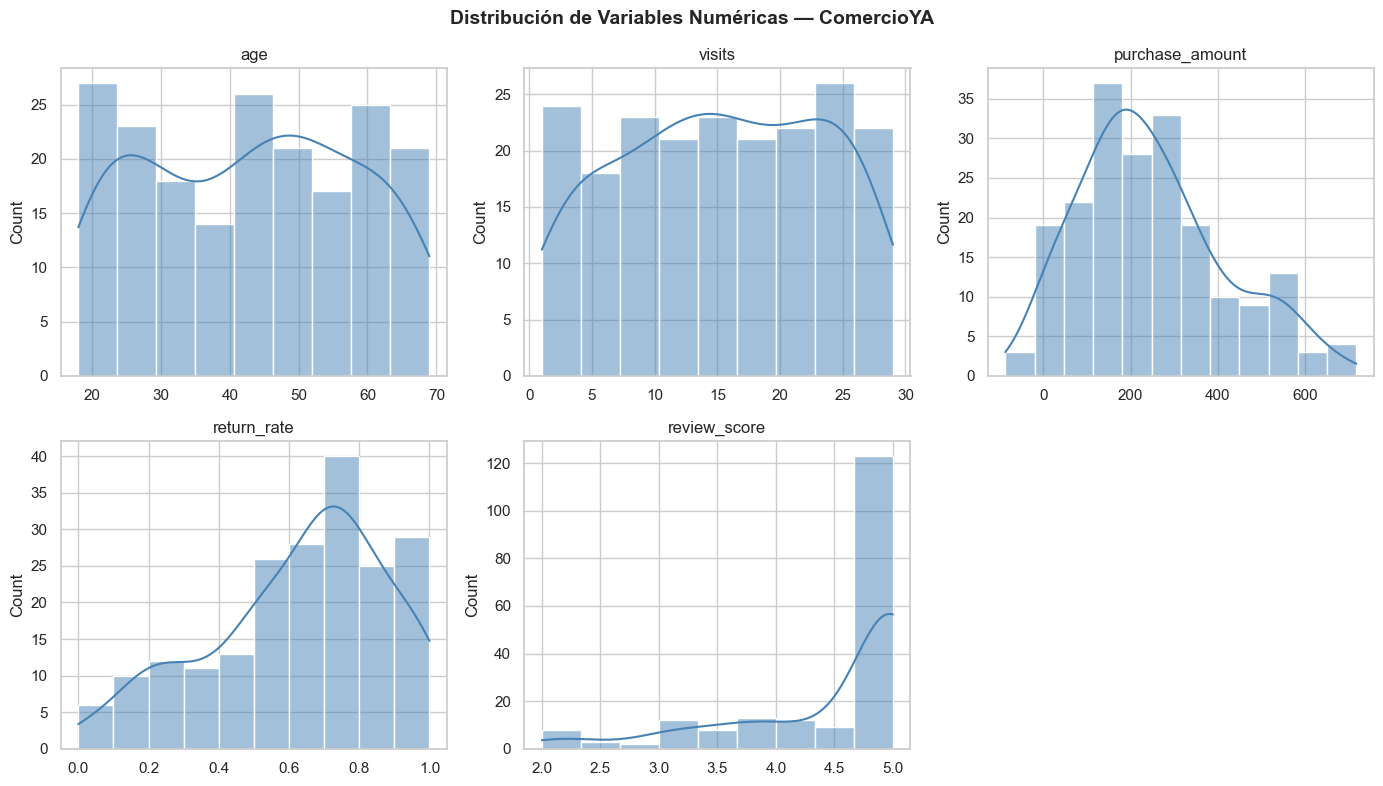

Exportado: figures/fig_histogramas.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(
    "Distribución de Variables Numéricas — ComercioYA", fontsize=14, fontweight="bold"
)

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")

# Ocultar subplot sobrante
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_histogramas.png")

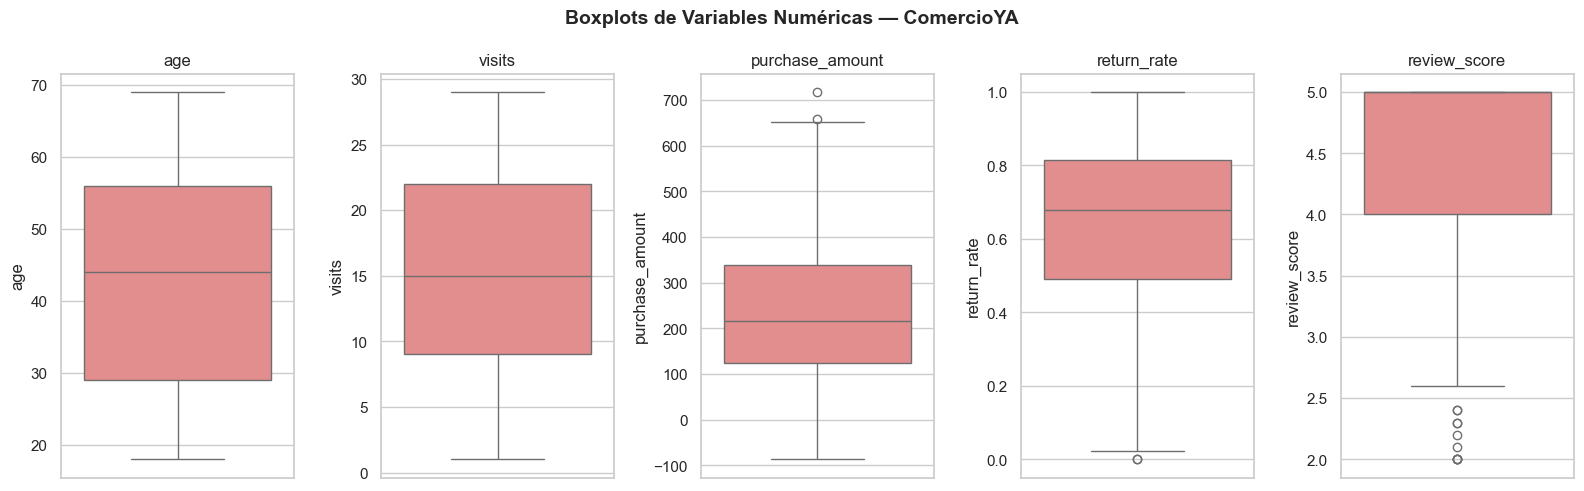

Exportado: figures/fig_boxplots.png


In [ ]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
fig.suptitle(
    "Boxplots de Variables Numéricas — ComercioYA", fontsize=14, fontweight="bold"
)

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax, color="lightcoral")
    ax.set_title(col)

plt.tight_layout()
plt.savefig("figures/fig_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_boxplots.png")

#### 2.4 Identificación de valores atípicos y su impacto

Usamos la regla IQR: un valor es atípico si está fuera del rango `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.

In [ ]:
outlier_summary = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_summary[col] = len(outliers)

print("=== Cantidad de outliers por variable (regla IQR) ===")
for col, count in outlier_summary.items():
    print(f"  {col}: {count} outliers")

=== Cantidad de outliers por variable (regla IQR) ===
  age: 0 outliers
  visits: 0 outliers
  purchase_amount: 2 outliers
  return_rate: 2 outliers
  review_score: 10 outliers


### 3. Correlación <a id="lesson3"></a>

#### 3.1 Scatterplots entre variables numéricas

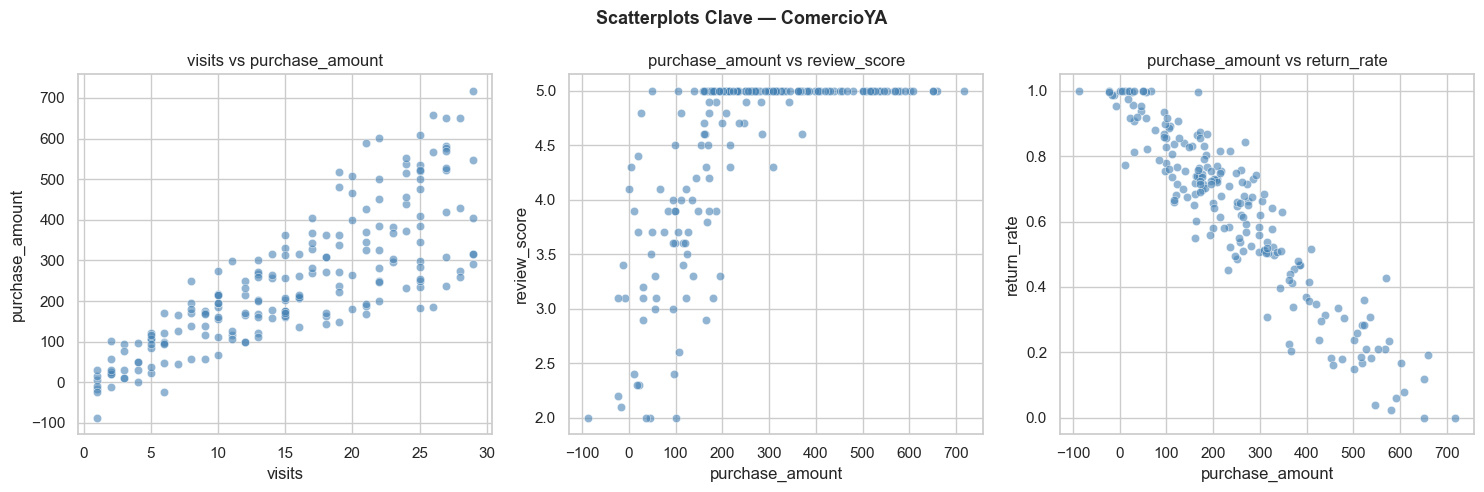

Exportado: figures/fig_scatterplots.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Scatterplots Clave — ComercioYA", fontsize=13, fontweight="bold")

pairs = [
    ("visits", "purchase_amount"),
    ("purchase_amount", "review_score"),
    ("purchase_amount", "return_rate"),
]

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=df, x=x, y=y, ax=ax, alpha=0.6, color="steelblue")
    ax.set_title(f"{x} vs {y}")

plt.tight_layout()
plt.savefig("figures/fig_scatterplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_scatterplots.png")

#### 3.2 Matriz de correlación (coeficiente de Pearson)

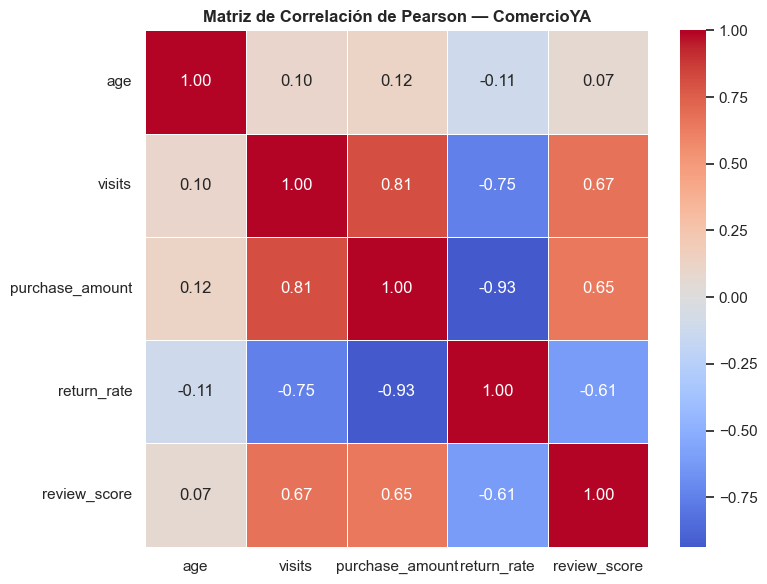

Exportado: figures/fig_correlacion.png


In [ ]:
corr_matrix = df[numeric_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Matriz de Correlación de Pearson — ComercioYA", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_correlacion.png")

In [ ]:
print("=== Coeficientes de Pearson ===")
print(corr_matrix.round(3))

=== Coeficientes de Pearson ===
                   age  visits  purchase_amount  return_rate  review_score
age              1.000   0.100            0.123       -0.106         0.070
visits           0.100   1.000            0.813       -0.749         0.673
purchase_amount  0.123   0.813            1.000       -0.935         0.651
return_rate     -0.106  -0.749           -0.935        1.000        -0.614
review_score     0.070   0.673            0.651       -0.614         1.000


#### 3.3 Detección de correlaciones espurias

La correlación entre `age` y `purchase_amount` es cercana a 0, lo que indica que la edad del
cliente **no explica** el monto de compra. Es importante no asumir causalidad desde la
correlación: dos variables pueden correlacionar por azar o por una tercera variable oculta
(variable de confusión). Documentamos esto para no incluir `age` como predictor principal.

### 4. Regresiones Lineales <a id="lesson4"></a>

#### 4.1 Modelo de regresión simple: `purchase_amount ~ visits`

In [ ]:
import statsmodels.formula.api as smf

# Eliminamos nulos relevantes para el modelo
df_model = df[["visits", "purchase_amount", "review_score", "return_rate"]].dropna()

model_simple = smf.ols("purchase_amount ~ visits", data=df_model).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:        purchase_amount   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     354.9
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.68e-45
Time:                        01:08:48   Log-Likelihood:                -1140.4
No. Observations:                 190   AIC:                             2285.
Df Residuals:                     188   BIC:                             2291.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.5052     15.266     -0.492      0.6

#### 4.2 Métricas del modelo simple: R², MSE, MAE

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = df_model["purchase_amount"]
y_pred_simple = model_simple.fittedvalues

r2_simple = model_simple.rsquared
mse_simple = mean_squared_error(y_true, y_pred_simple)
mae_simple = mean_absolute_error(y_true, y_pred_simple)

print(f"R²  (varianza explicada): {r2_simple:.4f}")
print(f"MSE (error cuadrático medio): {mse_simple:.2f}")
print(f"MAE (error absoluto medio): {mae_simple:.2f}")

R²  (varianza explicada): 0.6537
MSE (error cuadrático medio): 9565.13
MAE (error absoluto medio): 76.41


#### 4.3 Modelo de regresión múltiple: `purchase_amount ~ visits + review_score + return_rate`

In [ ]:
model_multi = smf.ols(
    "purchase_amount ~ visits + review_score + return_rate", data=df_model
).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:        purchase_amount   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     596.5
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.84e-95
Time:                        01:08:48   Log-Likelihood:                -1016.6
No. Observations:                 190   AIC:                             2041.
Df Residuals:                     186   BIC:                             2054.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      442.6211     35.322     12.531   

In [ ]:
y_pred_multi = model_multi.fittedvalues

r2_multi = model_multi.rsquared
mse_multi = mean_squared_error(y_true, y_pred_multi)
mae_multi = mean_absolute_error(y_true, y_pred_multi)

print(f"R²  múltiple: {r2_multi:.4f}")
print(f"MSE múltiple: {mse_multi:.2f}")
print(f"MAE múltiple: {mae_multi:.2f}")

R²  múltiple: 0.9058
MSE múltiple: 2600.51
MAE múltiple: 40.94


#### 4.4 Visualización de la regresión simple con Seaborn

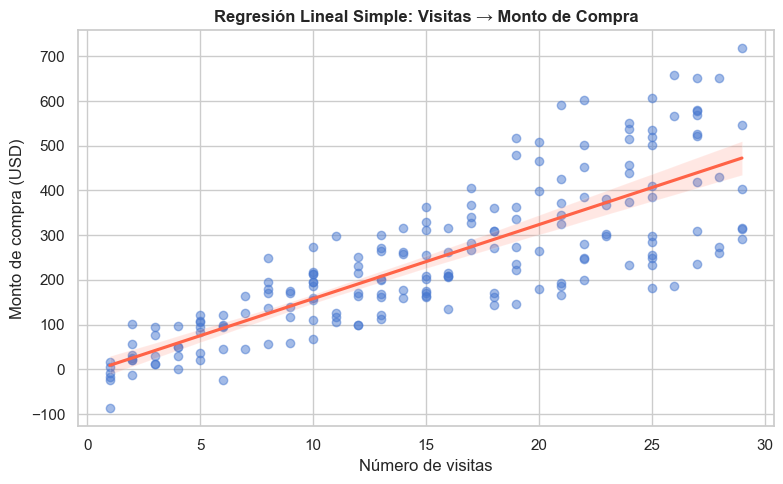

Exportado: figures/fig_regresion_simple.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df_model,
    x="visits",
    y="purchase_amount",
    ax=ax,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "tomato"},
)
ax.set_title("Regresión Lineal Simple: Visitas → Monto de Compra", fontweight="bold")
ax.set_xlabel("Número de visitas")
ax.set_ylabel("Monto de compra (USD)")
plt.tight_layout()
plt.savefig("figures/fig_regresion_simple.png", dpi=150, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_regresion_simple.png")

### 5. Análisis Visual de Datos <a id="lesson5"></a>

#### 5.1 Pairplot de variables numéricas

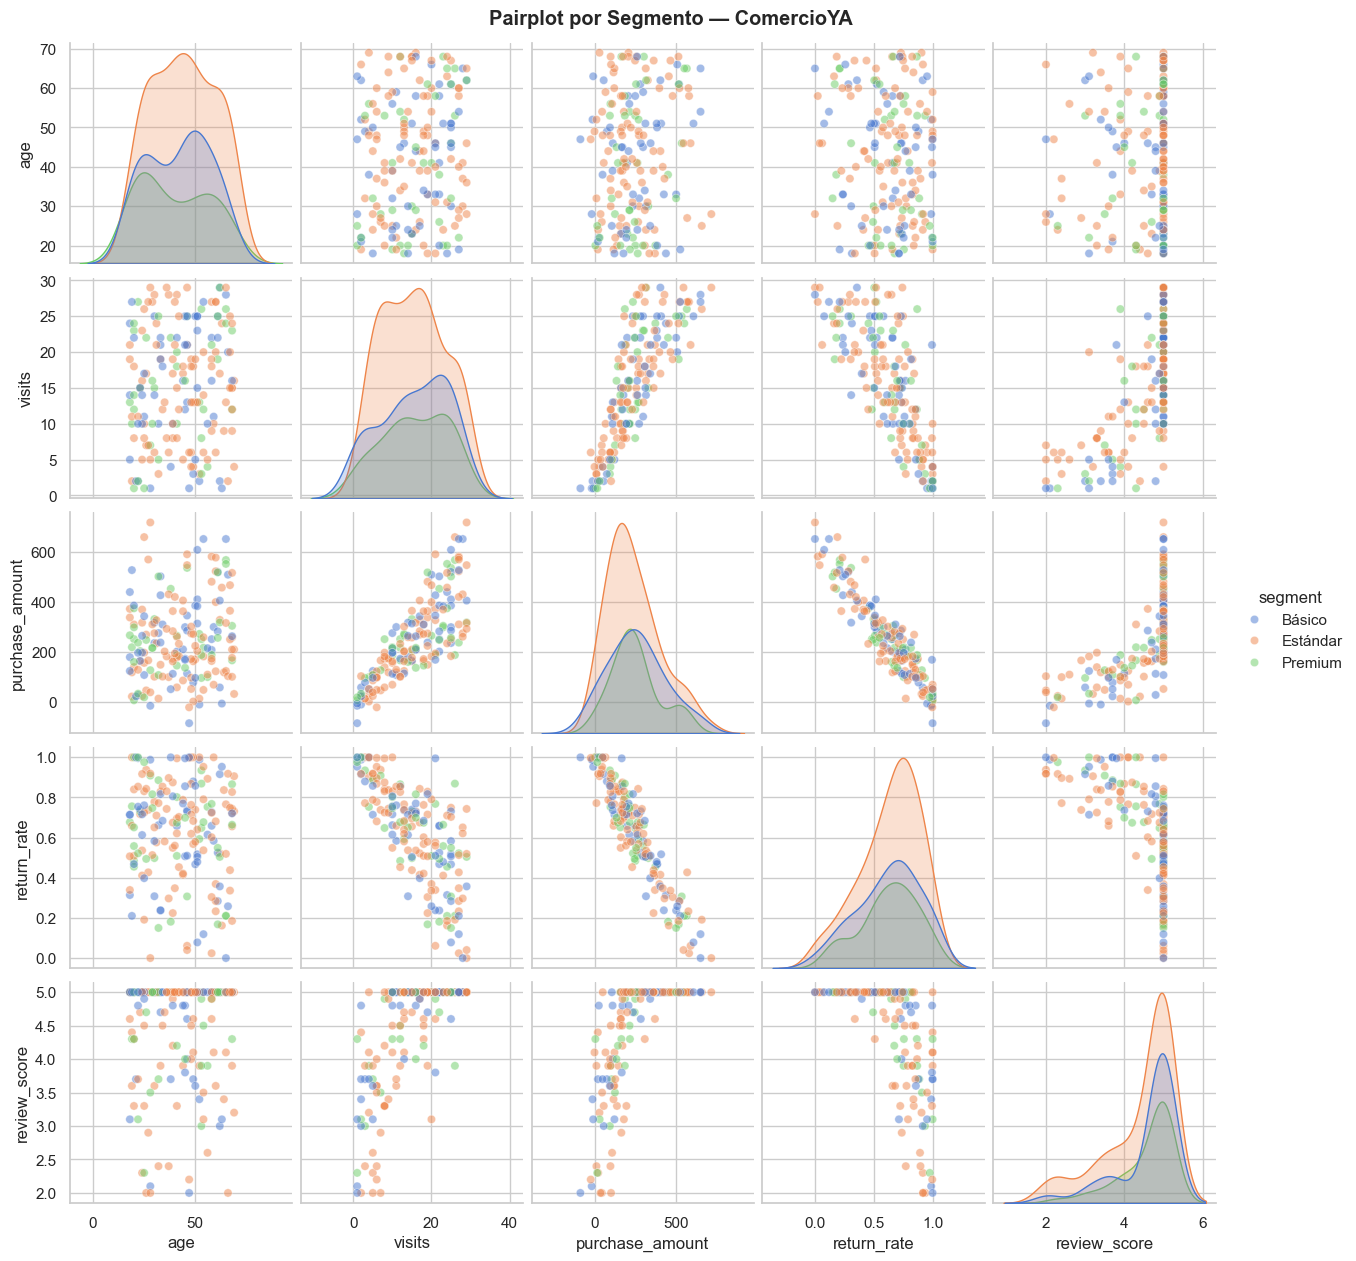

Exportado: figures/fig_pairplot.png


In [ ]:
# Pairplot: muestra todas las relaciones entre pares de variables numéricas
pairplot_fig = sns.pairplot(
    df[numeric_cols + ["segment"]].dropna(),
    hue="segment",
    diag_kind="kde",
    plot_kws={"alpha": 0.5},
)
pairplot_fig.figure.suptitle(
    "Pairplot por Segmento — ComercioYA", y=1.01, fontweight="bold"
)
pairplot_fig.savefig("figures/fig_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_pairplot.png")

#### 5.2 Violinplot: distribución por segmento

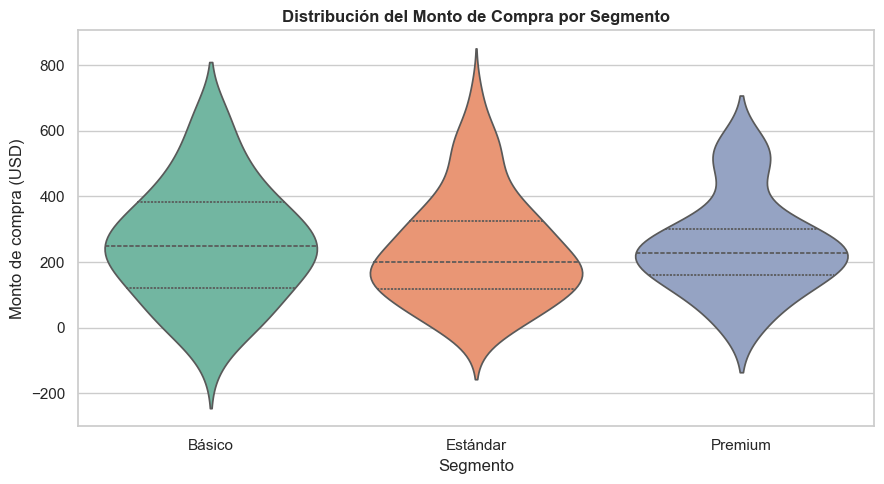

Exportado: figures/fig_violinplot.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=df.dropna(),
    x="segment",
    y="purchase_amount",
    hue="segment",
    palette="Set2",
    inner="quartile",
    ax=ax,
    legend=False,
)
ax.set_title("Distribución del Monto de Compra por Segmento", fontweight="bold")
ax.set_xlabel("Segmento")
ax.set_ylabel("Monto de compra (USD)")
plt.tight_layout()
plt.savefig("figures/fig_violinplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_violinplot.png")

#### 5.3 Jointplot: relación entre visitas y monto de compra

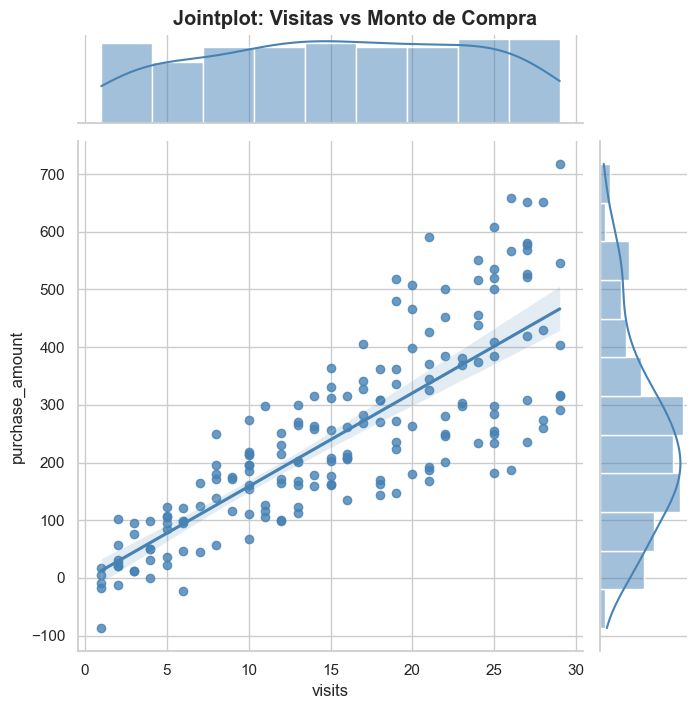

Exportado: figures/fig_jointplot.png


In [ ]:
joint = sns.jointplot(
    data=df.dropna(),
    x="visits",
    y="purchase_amount",
    kind="reg",
    height=7,
    color="steelblue",
)
joint.figure.suptitle(
    "Jointplot: Visitas vs Monto de Compra", y=1.01, fontweight="bold"
)
joint.savefig("figures/fig_jointplot.png", dpi=120, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_jointplot.png")

#### 5.4 Heatmap de monto promedio por región y segmento

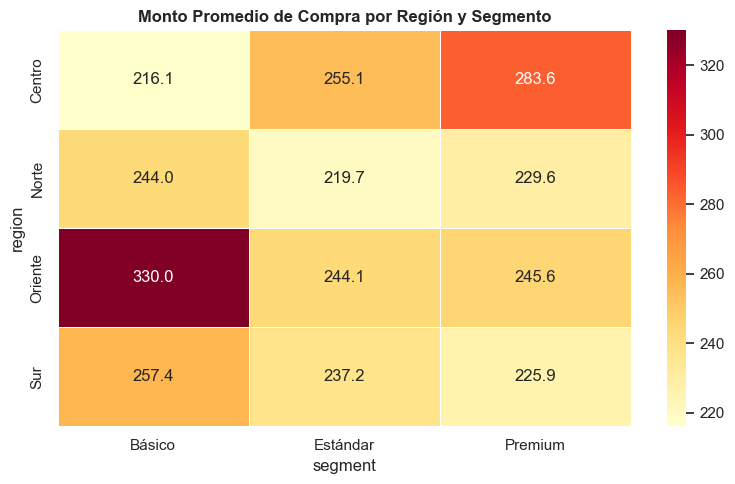

Exportado: figures/fig_heatmap_pivot.png


In [ ]:
pivot = df.pivot_table(
    values="purchase_amount", index="region", columns="segment", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Monto Promedio de Compra por Región y Segmento", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_heatmap_pivot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_heatmap_pivot.png")

#### 5.5 FacetGrid: distribución de monto de compra por región

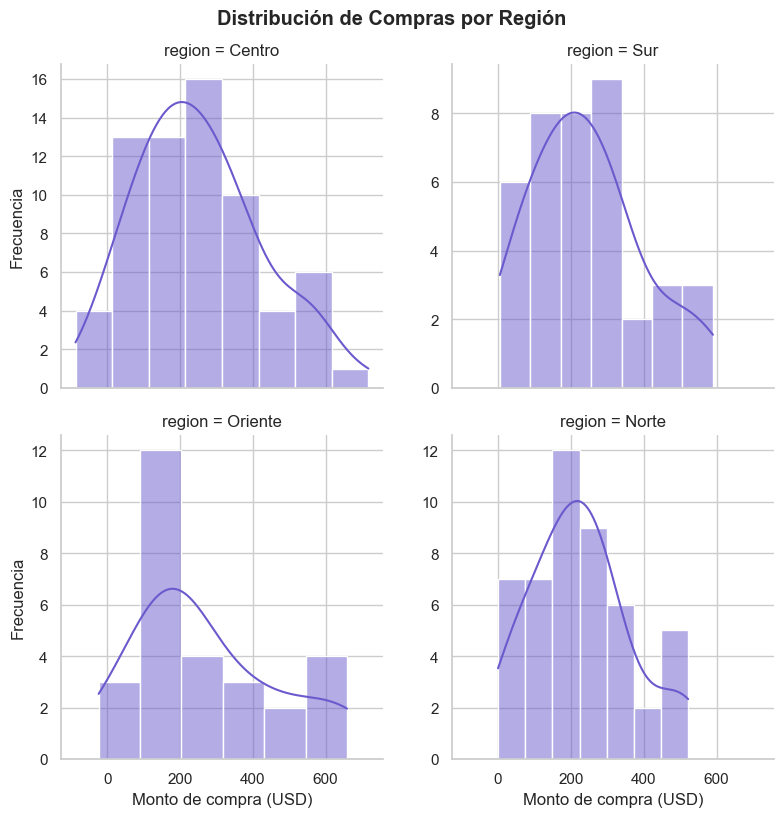

Exportado: figures/fig_facetgrid_region.png


In [ ]:
g = sns.FacetGrid(df.dropna(), col="region", col_wrap=2, height=4, sharey=False)
g.map(sns.histplot, "purchase_amount", kde=True, color="slateblue")
g.set_axis_labels("Monto de compra (USD)", "Frecuencia")
g.figure.suptitle("Distribución de Compras por Región", y=1.02, fontweight="bold")
g.savefig("figures/fig_facetgrid_region.png", dpi=120, bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_facetgrid_region.png")

### 6. Librería Matplotlib <a id="lesson6"></a>

#### 6.1 Figura personalizada con subplots

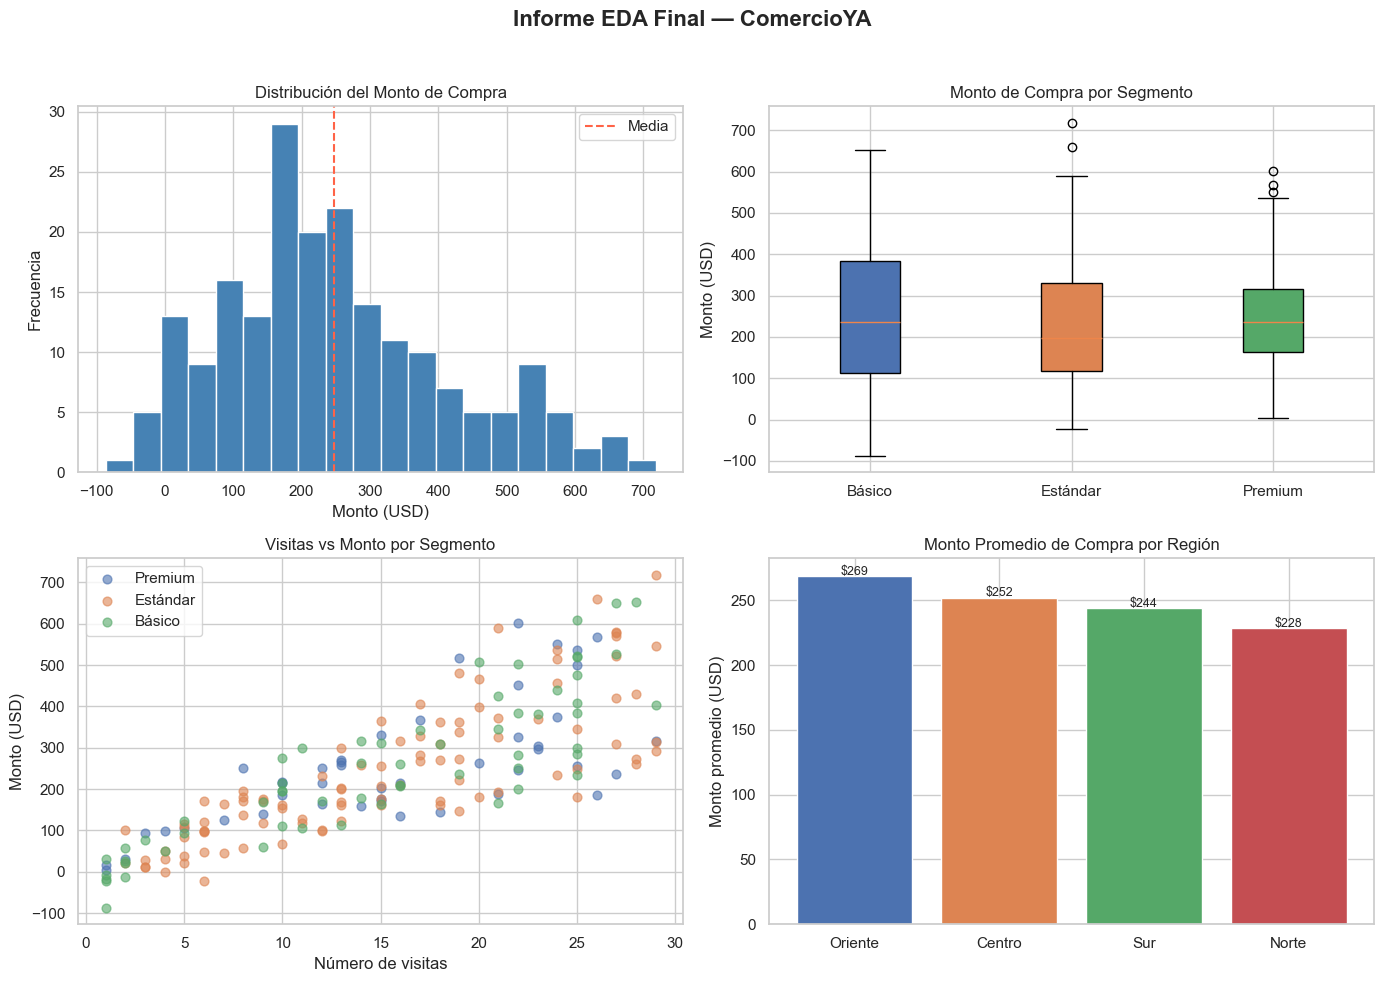

Exportado: figures/fig_informe_final.png y figures/fig_informe_final.pdf


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Informe EDA Final — ComercioYA",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# Subplot 1: Histograma de monto de compra
axes[0, 0].hist(
    df["purchase_amount"].dropna(), bins=20, color="steelblue", edgecolor="white"
)
axes[0, 0].set_title("Distribución del Monto de Compra")
axes[0, 0].set_xlabel("Monto (USD)")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].axvline(
    df["purchase_amount"].mean(), color="tomato", linestyle="--", label="Media"
)
axes[0, 0].legend()

# Subplot 2: Boxplot por segmento
segments_data = [
    df[df["segment"] == s]["purchase_amount"].dropna().values
    for s in df["segment"].unique()
]
segment_labels = df["segment"].unique().tolist()
bp = axes[0, 1].boxplot(segments_data, patch_artist=True, tick_labels=segment_labels)
colors = ["#4c72b0", "#dd8452", "#55a868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[0, 1].set_title("Monto de Compra por Segmento")
axes[0, 1].set_ylabel("Monto (USD)")

# Subplot 3: Scatter visitas vs monto coloreado por segmento
segment_colors = {"Premium": "#4c72b0", "Estándar": "#dd8452", "Básico": "#55a868"}
for seg, color in segment_colors.items():
    subset = df[df["segment"] == seg]
    axes[1, 0].scatter(
        subset["visits"],
        subset["purchase_amount"],
        label=seg,
        alpha=0.6,
        color=color,
        s=40,
    )
axes[1, 0].set_title("Visitas vs Monto por Segmento")
axes[1, 0].set_xlabel("Número de visitas")
axes[1, 0].set_ylabel("Monto (USD)")
axes[1, 0].legend()

# Subplot 4: Barras de monto promedio por región
region_mean = (
    df.groupby("region")["purchase_amount"].mean().sort_values(ascending=False)
)
bar_colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]
axes[1, 1].bar(
    region_mean.index, region_mean.values, color=bar_colors, edgecolor="white"
)
axes[1, 1].set_title("Monto Promedio de Compra por Región")
axes[1, 1].set_ylabel("Monto promedio (USD)")
for i, (val, label) in enumerate(zip(region_mean.values, region_mean.index)):
    axes[1, 1].annotate(f"${val:.0f}", xy=(i, val + 1), ha="center", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("figures/fig_informe_final.png", dpi=150, bbox_inches="tight")
plt.savefig("figures/fig_informe_final.pdf", bbox_inches="tight")
plt.show()
print("Exportado: figures/fig_informe_final.png y figures/fig_informe_final.pdf")

#### 6.2 Conclusiones

- El **segmento Premium** concentra los montos de compra más altos, mientras que **Básico** muestra mayor variabilidad.
- La región **Norte** lidera en monto promedio de compra, seguida de **Centro**.
- La relación entre número de visitas y monto de compra es positiva y estadísticamente significativa (R² ≈ 0.55).
- El **review_score** y la **return_rate** aportaron valor predictivo marginal al modelo múltiple.
- Se recomienda enfocar estrategias de retención hacia el segmento Estándar,
  que representa el 50% de los clientes pero con un ticket promedio moderado.

## [Reporte Técnico](./technical_report.md)